In [1]:
import os
os.chdir(r"C:\Users\Rinku\Desktop\mutual-fund-analysis")
print(os.getcwd())

C:\Users\Rinku\Desktop\mutual-fund-analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
nav = pd.read_csv("data/processed/clean_nav.csv")

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[us]
nav                 float64
dtype: object


In [5]:
nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


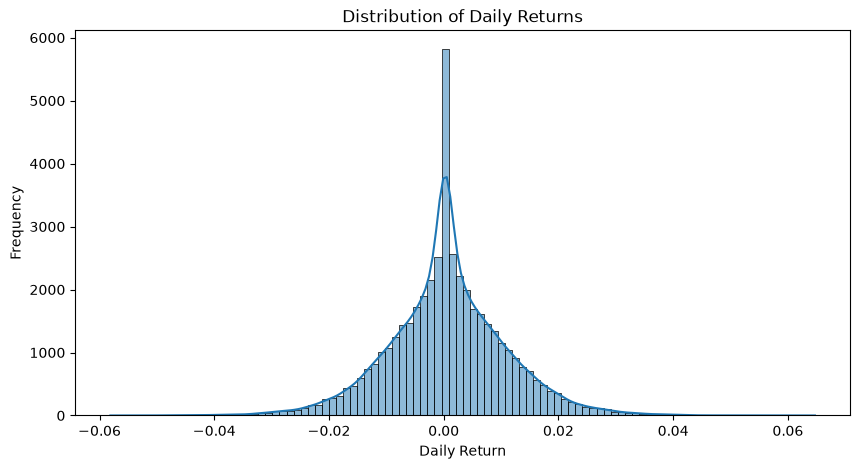

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(nav["daily_return"].dropna(), bins=100, kde=True)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [8]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [9]:
cagr_data = []

for fund in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == fund]
    
    start_nav = fund_data["nav"].iloc[0]
    end_nav = fund_data["nav"].iloc[-1]

    cagr_1y = calculate_cagr(start_nav, end_nav, 1)
    cagr_3y = calculate_cagr(start_nav, end_nav, 3)
    cagr_5y = calculate_cagr(start_nav, end_nav, 5)

    cagr_data.append([
        fund,
        cagr_1y,
        cagr_3y,
        cagr_5y
    ])

In [10]:
cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code", "cagr_1y", "cagr_3y", "cagr_5y"]
)

cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,0.121336,0.038912,0.023168
1,100025,0.211552,0.066058,0.039127
2,100033,2.185142,0.471328,0.260741
3,101206,1.534562,0.363435,0.204427
4,101207,0.399496,0.118555,0.069533


In [11]:
risk_free_rate = 0.065

In [12]:
sharpe_data = []

for fund in nav["amfi_code"].unique():
    fund_returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    mean_return = fund_returns.mean() * 252
    volatility = fund_returns.std() * np.sqrt(252)

    sharpe_ratio = (mean_return - risk_free_rate) / volatility

    sharpe_data.append([fund, sharpe_ratio])

In [13]:
fund_returns.mean() * 252

np.float64(0.300931229977172)

In [15]:
sharpe_data = []

for fund in nav["amfi_code"].unique():
    fund_returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    mean_return = fund_returns.mean() * 252
    volatility = fund_returns.std() * np.sqrt(252)

    sharpe_ratio = (mean_return - risk_free_rate) / volatility

    sharpe_data.append([fund, sharpe_ratio])

In [16]:
sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [17]:
sortino_data = []

for fund in nav["amfi_code"].unique():
    fund_returns = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    mean_return = fund_returns.mean() * 252
    
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std() * np.sqrt(252)

    sortino_ratio = (mean_return - risk_free_rate) / downside_std

    sortino_data.append([fund, sortino_ratio])

In [18]:
sortino_df = pd.DataFrame(
    sortino_data,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [19]:
import os
print(os.listdir("data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'axis_bluechip_nav.csv', 'hdfc_live_nav.csv', 'icici_bluechip_nav.csv', 'kotak_bluechip_nav.csv', 'nippon_large_cap_nav.csv', 'sbi_bluechip_nav.csv']


In [20]:
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

print(benchmark.shape)
benchmark.head()

(8050, 3)


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [21]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [22]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

print(nifty100.shape)
nifty100.head()

(1150, 3)


,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [23]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

nifty100["market_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,market_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [24]:
merged = nav.merge(
    nifty100[["date", "market_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,market_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [25]:
alpha_beta_data = []

for fund in merged["amfi_code"].unique():
    fund_data = merged[merged["amfi_code"] == fund].dropna()

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        fund_data["market_return"],
        fund_data["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta_data.append([fund, alpha, beta])

In [26]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_data,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [27]:
drawdown_data = []

for fund in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == fund].copy()

    fund_data["running_max"] = fund_data["nav"].cummax()
    
    fund_data["drawdown"] = (
        fund_data["nav"] / fund_data["running_max"]
    ) - 1

    max_drawdown = fund_data["drawdown"].min()

    drawdown_data.append([fund, max_drawdown])

In [28]:
drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df = drawdown_df.sort_values("max_drawdown")

drawdown_df.head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [29]:
performance = pd.read_csv("data/processed/clean_performance.csv")

print(performance.shape)
performance.head()

(40, 19)


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [30]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
).merge(
    alpha_beta_df,
    on="amfi_code"
).merge(
    drawdown_df,
    on="amfi_code"
).merge(
    performance[["amfi_code", "expense_ratio_pct"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct
0,100016,0.121336,0.038912,0.023168,-0.201517,0.037476,-0.058268,-0.247344,1.55
1,100025,0.211552,0.066058,0.039127,-0.567095,0.042818,0.001158,-0.043083,0.56
2,100033,2.185142,0.471328,0.260741,1.093699,0.271954,0.005104,-0.162172,1.38
3,101206,1.534562,0.363435,0.204427,1.027213,0.213998,0.021086,-0.112916,1.60
4,101207,0.399496,0.118555,0.069533,0.162661,0.108971,-0.065289,-0.354469,1.53


In [31]:
scorecard["rank_cagr"] = scorecard["cagr_3y"].rank(ascending=False)
scorecard["rank_sharpe"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["rank_alpha"] = scorecard["alpha"].rank(ascending=False)

scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["rank_drawdown"] = scorecard["max_drawdown"].rank(ascending=False)

In [32]:
scorecard["fund_score"] = (
    (scorecard["rank_cagr"] * 0.30) +
    (scorecard["rank_sharpe"] * 0.25) +
    (scorecard["rank_alpha"] * 0.20) +
    (scorecard["rank_expense"] * 0.15) +
    (scorecard["rank_drawdown"] * 0.10)
)

In [33]:
scorecard["fund_score"] = 100 - (
    (scorecard["fund_score"] / scorecard["fund_score"].max()) * 100
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[["amfi_code", "fund_score"]].head()

,amfi_code,fund_score
25,120505,80.926054
34,148567,79.543884
30,120843,78.161714
2,100033,73.462336
36,148569,71.458189


In [34]:
top5_funds = scorecard["amfi_code"].head(5).tolist()

print(top5_funds)


[120505, 148567, 120843, 100033, 148569]


In [35]:
top5_nav = nav[nav["amfi_code"].isin(top5_funds)]

print(top5_nav.shape)

(5750, 4)


In [36]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark_filtered = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
]

benchmark_filtered.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


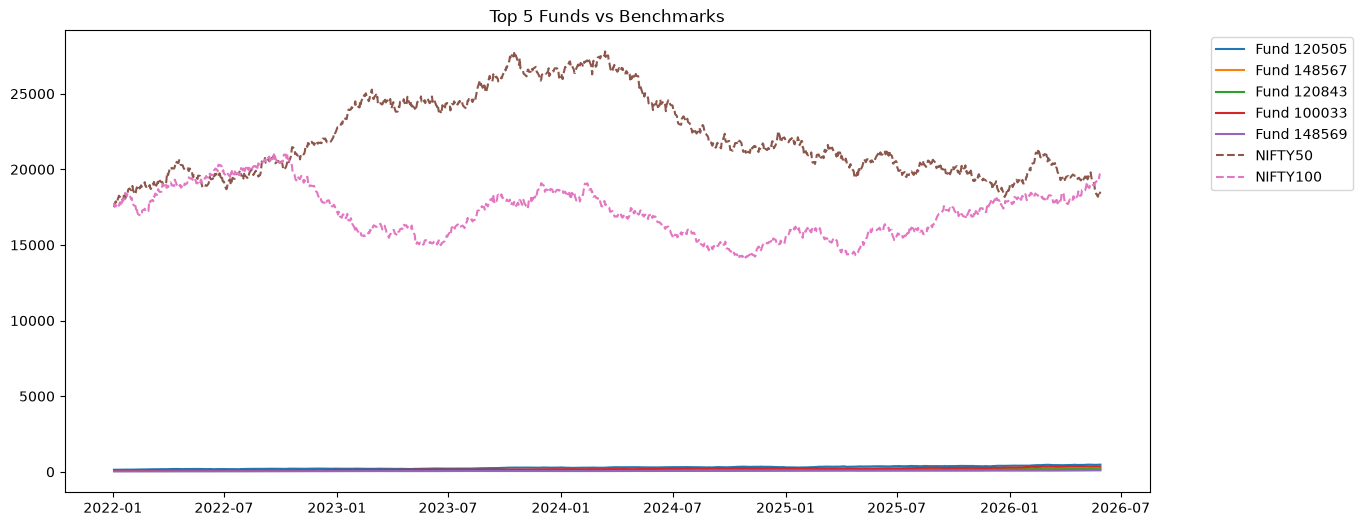

In [37]:
plt.figure(figsize=(14,6))

for fund in top5_funds:
    fund_data = top5_nav[top5_nav["amfi_code"] == fund]
    plt.plot(fund_data["date"], fund_data["nav"], label=f"Fund {fund}")

for index_name in ["NIFTY50", "NIFTY100"]:
    index_data = benchmark_filtered[
        benchmark_filtered["index_name"] == index_name
    ]
    plt.plot(
        index_data["date"],
        index_data["close_value"],
        linestyle="--",
        label=index_name
    )

plt.title("Top 5 Funds vs Benchmarks")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.show()

In [38]:
tracking_error_data = []

for fund in top5_funds:
    fund_data = merged[merged["amfi_code"] == fund].dropna()

    active_return = (
        fund_data["daily_return"] - fund_data["market_return"]
    )

    tracking_error = active_return.std() * np.sqrt(252)

    tracking_error_data.append([fund, tracking_error])

In [39]:
tracking_error_df = pd.DataFrame(
    tracking_error_data,
    columns=["amfi_code", "tracking_error"]
)

tracking_error_df

,amfi_code,tracking_error
0,120505,0.231968
1,148567,0.189664
2,120843,0.206425
3,100033,0.228699
4,148569,0.217365


In [40]:
scorecard.to_csv("reports/fund_scorecard.csv", index=False)

print("fund_scorecard.csv saved!")

fund_scorecard.csv saved!


In [41]:
alpha_beta_df.to_csv("reports/alpha_beta.csv", index=False)

print("alpha_beta.csv saved!")

alpha_beta.csv saved!


In [42]:
plt.savefig("reports/benchmark_comparison.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>